In [1]:
from pathlib import Path
import cv2
import numpy as np
from PIL import Image
import torch
import json
from torch.utils.data import Dataset
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# Explorative Data Analysis for DoTA dataset

### Define dataset

In [2]:
import cv2
import json
import torch
from pathlib import Path
from kornia.geometry import resize
from torch.utils.data import Dataset

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class SupervisedDataset(Dataset):
    def __init__(self, path_to_data: str, which_set: str, resize_target: tuple = (227, 227)):

        assert which_set in ['train', 'val', 'test'], f"which_set must be one of ['train', 'val', 'test'], got {which_set}"

        self.path_to_data = Path(path_to_data) # datasets\DoTA
        self.data, self.labels = self._load_data(which_set) # dataset\DoTA\frames
        self.resize_target = resize_target

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img = torch.tensor(cv2.imread(str(self.data[idx]), cv2.IMREAD_COLOR_RGB))
        if len(img.shape) == 2:
            img = img.unsqueeze(2)
        img = img.permute(2, 0, 1).float() / 255.
        img = resize(img, self.resize_target)

        return img, self.labels[idx]
        

    def _load_data(self, which_set: str):
        video_paths = sorted([directory 
                              for directory 
                              in (self.path_to_data / 'frames' / which_set).iterdir() 
                              if directory.is_dir()])
        
        label_paths = sorted([label 
                              for label 
                              in (self.path_to_data / 'annotations' / which_set).rglob('*.json')])
        
        data = []
        targets = None

        for video_path, label_path in zip(video_paths, label_paths):
            video_name = video_path.name
            label_name = label_path.name.replace('.json', '')
            assert video_name == label_name, f"Video name {video_name} does not match label name {label_name}"

            # Load the labels
            with open(label_path, 'r') as f:
                labels = json.load(f)
                accident_id = labels['accident_id']
                start = labels['anomaly_start']
                end = labels['anomaly_end']

            # Filter the frames
            video_path = video_path / 'images'
            frames = [frame for frame in video_path.rglob('*.jpg')]
            labels = torch.cat([torch.zeros(start), torch.full(size=(end - start,), fill_value=int(accident_id)), torch.zeros(len(frames) - end)])

            data.extend(frames)
            if targets is None:
                targets = labels
            else:
                targets = torch.cat([targets, labels])

        return data, targets

### Initialize dataset

In [3]:
dataset_path = r"D:\MAGISTERKA\anomaly_traffic_road\datasets\DoTA"

train_dataset = SupervisedDataset(dataset_path, "train")
val_dataset = SupervisedDataset(dataset_path, "val")
test_dataset = SupervisedDataset(dataset_path, "test")

print(f"Training set length: {len(train_dataset.data)} images and {len(train_dataset.labels)} labels")
print(f"Validation set length: {len(val_dataset.data)} images and {len(val_dataset.labels)} labels")
print(f"Test set length: {len(test_dataset.data)} images and {len(test_dataset.labels)} labels")

Training set length: 337940 images and 337940 labels
Validation set length: 72093 images and 72093 labels
Test set length: 70654 images and 70654 labels


### Types of labels:

In [4]:
fetched_labels = []
labels_names = np.full(11, fill_value="class_name")
labels_names[0] = "normal"

dataset_path = r"D:\MAGISTERKA\anomaly_traffic_road\datasets\DoTA"

labels_path = Path(dataset_path) / "annotations" / "train"
labels_files = sorted(list(labels_path.glob("*.json")))

for label_file in tqdm(labels_files, desc=f"Loading labels in train set", total=len(labels_files)):
    with open(label_file, "r") as file:
        labels = json.load(file)
        if labels_names[int(labels["accident_id"])] == "class_name":
            labels_names[int(labels["accident_id"])] = labels["accident_name"]
        labels = [label["accident_id"] for label in labels["labels"]]
        fetched_labels.extend(labels)

for i, c_name in enumerate(labels_names):
    print(f"{i}: {c_name}")


Loading labels in train set:   0%|          | 0/3275 [00:00<?, ?it/s]

0: normal
1: start_stop
2: moving_ahe
3: lateral
4: oncoming
5: turning
6: pedestrian
7: obstacle
8: leave_to_r
9: leave_to_l
10: unknown


### Random sequence

tensor(246173)


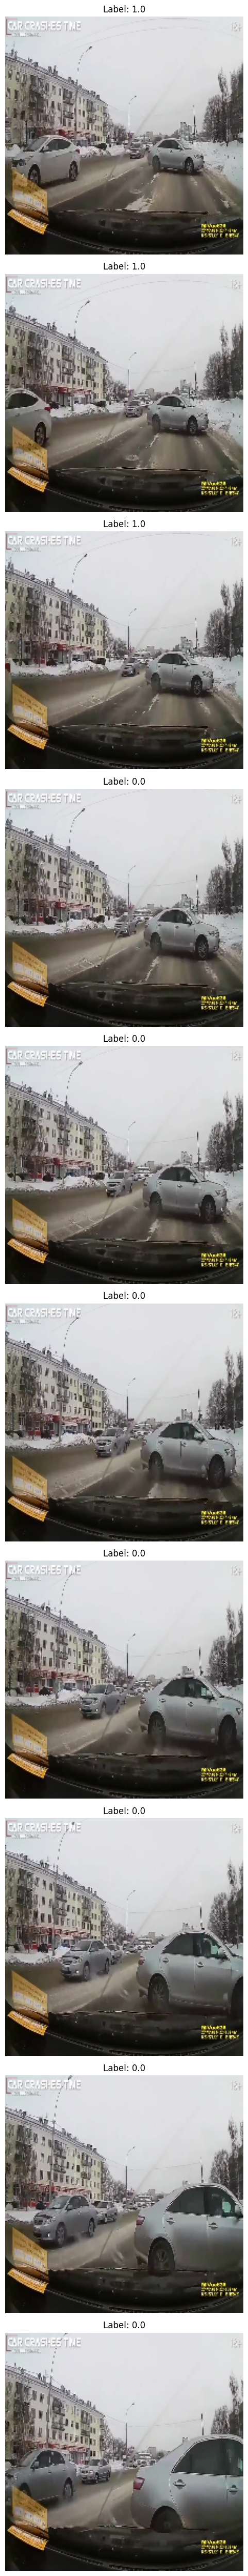

In [5]:
from random import choice

anomalies = torch.where(train_dataset.labels == 1)
idx = choice(anomalies[0])
print(idx)
fig, axs = plt.subplots(10, 1, figsize=(5, 50))
for i in range(10):
    axs[i].imshow(train_dataset[idx+i][0].permute(1, 2, 0))
    axs[i].set_title(f"Label: {train_dataset.labels[idx+i]}")
    axs[i].axis("off")
plt.tight_layout()
plt.show()

### Check class balance

C:\Users\lukas\AppData\Local\Temp\ipykernel_50904\4227122088.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  unique_labels = torch.unique(torch.tensor(labels, dtype=torch.int64))


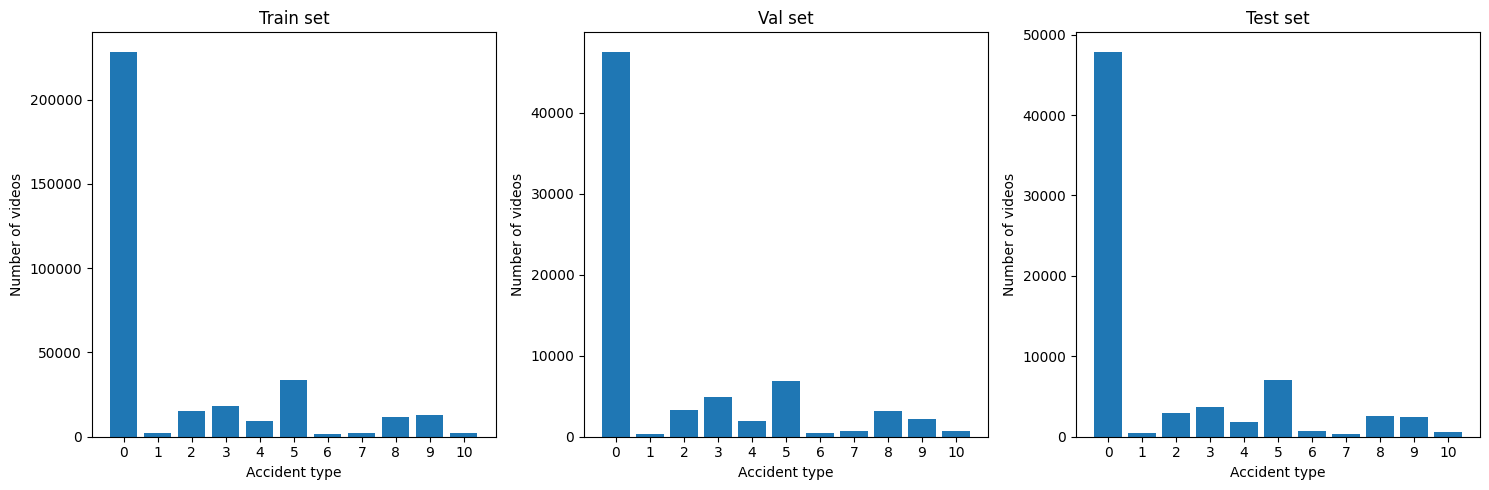

In [6]:
train_labels = train_dataset.labels.type(torch.int64)
val_labels = val_dataset.labels.type(torch.int64)
test_labels = test_dataset.labels.type(torch.int64)


fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for i, labels in enumerate([train_labels, val_labels, test_labels]):
    unique_labels = torch.unique(torch.tensor(labels, dtype=torch.int64))
    class_counts = torch.bincount(labels)
    axs[i].bar(unique_labels, class_counts)
    axs[i].set_title(f"{['train', 'val', 'test'][i].capitalize()} set")
    axs[i].set_xlabel("Accident type")
    axs[i].set_ylabel("Number of videos")
    axs[i].set_xticks(unique_labels)

plt.tight_layout()
plt.show()

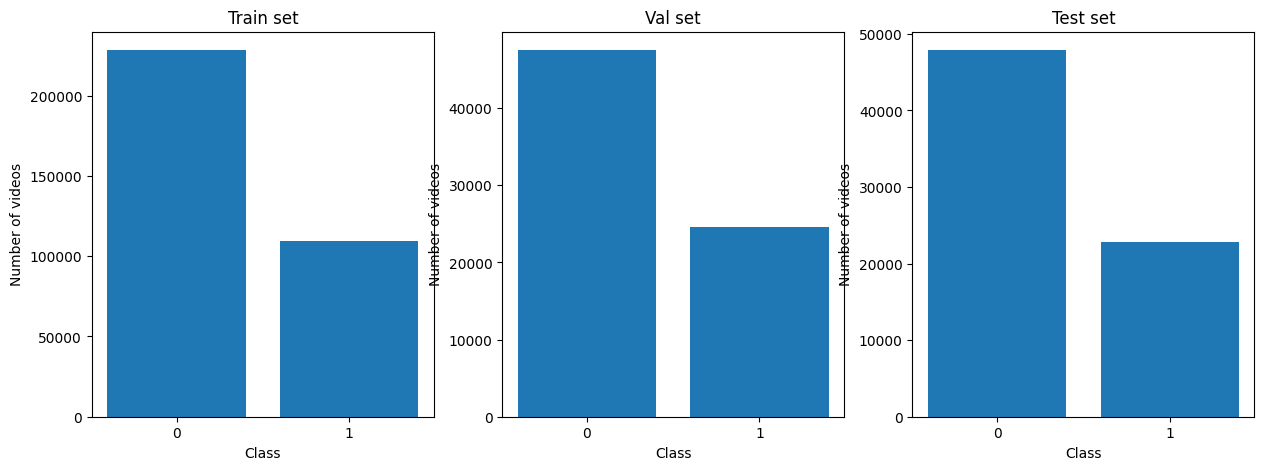

In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15,5))

for i, labels in enumerate([train_labels, val_labels, test_labels]):
    unique_labels = torch.tensor([0, 1])
    class_counts = torch.bincount(labels)
    class_counts = torch.tensor([class_counts[0].item(), torch.sum(class_counts[1:]).item()])
    axs[i].bar(unique_labels, class_counts)
    axs[i].set_title(f"{['train', 'val', 'test'][i].capitalize()} set")
    axs[i].set_xlabel("Class")
    axs[i].set_ylabel("Number of videos")
    axs[i].set_xticks(unique_labels)

### Pixel differences between classes

  0%|          | 0/11426 [00:00<?, ?it/s]

  0%|          | 0/11426 [00:00<?, ?it/s]

  0%|          | 0/11426 [00:00<?, ?it/s]

  0%|          | 0/11426 [00:00<?, ?it/s]

  0%|          | 0/11426 [00:00<?, ?it/s]

...

  0%|          | 0/5472 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5472 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

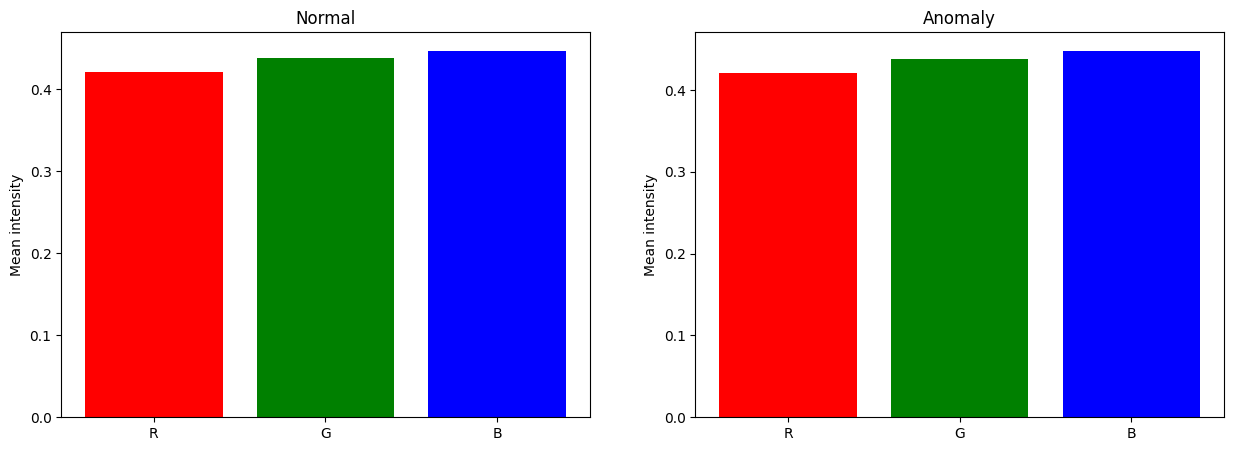

In [8]:
normal_indices = torch.where(train_labels == 0)[0]
anomaly_indices = torch.where(train_labels != 0)[0]

from concurrent.futures import ThreadPoolExecutor
import numpy as np
import os

def calculate_mean(indices, dataset, desc=None):
    mean = torch.zeros(3, 227, 227)
    for i in tqdm(indices, desc=desc, leave=False):
        mean += dataset[i][0]
    return mean

# Podziel indeksy na mniejsze partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    anomaly_chunks = split_indices(anomaly_indices)
    
    # Oblicz średnie dla każdej partii
    normal_means = list(executor.map(lambda chunk: calculate_mean(chunk, train_dataset), normal_chunks))
    anomaly_means = list(executor.map(lambda chunk: calculate_mean(chunk, train_dataset), anomaly_chunks))

# Zsumuj wyniki
mean_normal = sum(normal_means) / len(normal_indices)
mean_anomaly = sum(anomaly_means) / len(anomaly_indices)

mean_normal_r = mean_normal[0].mean()
mean_normal_g = mean_normal[1].mean()
mean_normal_b = mean_normal[2].mean()

mean_anomaly_r = mean_anomaly[0].mean()
mean_anomaly_g = mean_anomaly[1].mean()
mean_anomaly_b = mean_anomaly[2].mean()

fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].bar(range(3), [mean_anomaly_r, mean_normal_g, mean_normal_b], color=["red", "green", "blue"])
axs[0].set_title("Normal")
axs[0].set_ylabel("Mean intensity")
axs[0].set_xticks(range(3), ["R", "G", "B"])
axs[1].bar(range(3), [mean_anomaly_r, mean_anomaly_g, mean_anomaly_b], color=["red", "green", "blue"])
axs[1].set_title("Anomaly")
axs[1].set_ylabel("Mean intensity")
axs[1].set_xticks(range(3), ["R", "G", "B"])

  0%|          | 0/11426 [00:00<?, ?it/s]

  0%|          | 0/11426 [00:00<?, ?it/s]

  0%|          | 0/11426 [00:00<?, ?it/s]

  0%|          | 0/11426 [00:00<?, ?it/s]

  0%|          | 0/11426 [00:00<?, ?it/s]

...

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

  0%|          | 0/5471 [00:00<?, ?it/s]

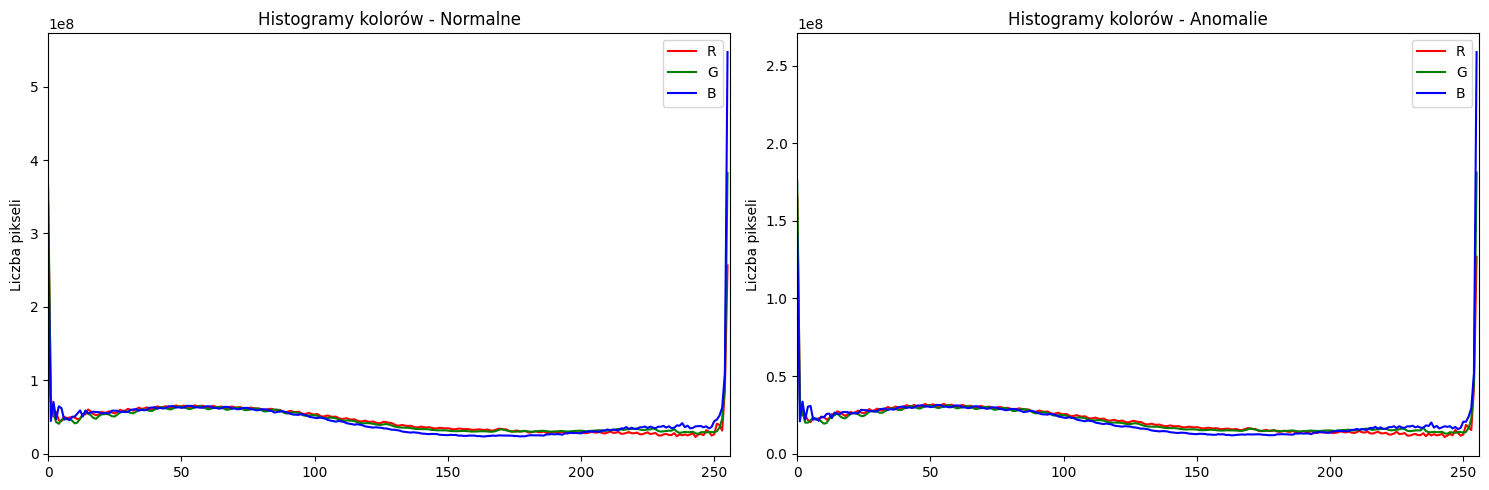

In [9]:
def calculate_histograms(indices, dataset, desc=None):
    hist_r = torch.zeros(256)
    hist_g = torch.zeros(256)
    hist_b = torch.zeros(256)
    for i in tqdm(indices, desc=desc, leave=False):
        img = dataset[i][0]
        hist_r += torch.histc(img[0], bins=256, min=0, max=1)
        hist_g += torch.histc(img[1], bins=256, min=0, max=1)
        hist_b += torch.histc(img[2], bins=256, min=0, max=1)
    return hist_r, hist_g, hist_b

# Podziel indeksy na mniejsze partie
def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

# Zrównoleglone obliczenia
with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
    # Podziel indeksy na partie
    normal_chunks = split_indices(normal_indices)
    anomaly_chunks = split_indices(anomaly_indices)
    
    # Oblicz średnie dla każdej partii
    normal_results = list(executor.map(lambda chunk: calculate_histograms(chunk, train_dataset), normal_chunks))
    anomaly_results = list(executor.map(lambda chunk: calculate_histograms(chunk, train_dataset), anomaly_chunks))

normal_hist_r = torch.zeros(256)
normal_hist_g = torch.zeros(256)
normal_hist_b = torch.zeros(256)

anomaly_hist_r = torch.zeros(256)
anomaly_hist_g = torch.zeros(256)
anomaly_hist_b = torch.zeros(256)

for r, g, b in normal_results:
    normal_hist_r += r
    normal_hist_g += g
    normal_hist_b += b

for r, g, b in anomaly_results:
    anomaly_hist_r += r
    anomaly_hist_g += g
    anomaly_hist_b += b

# Wizualizacja histogramów
fig, axs = plt.subplots(1, 2, figsize=(15, 5))

# Wykres dla obrazów normalnych
axs[0].plot(range(256), normal_hist_r.numpy(), color='red', label='R')
axs[0].plot(range(256), normal_hist_g.numpy(), color='green', label='G')
axs[0].plot(range(256), normal_hist_b.numpy(), color='blue', label='B')
axs[0].set_title('Histogramy kolorów - Normalne')
axs[0].set_xlim([0, 256])
axs[0].set_ylabel('Liczba pikseli')
axs[0].legend()

# Wykres dla anomalii
axs[1].plot(range(256), anomaly_hist_r.numpy(), color='red', label='R')
axs[1].plot(range(256), anomaly_hist_g.numpy(), color='green', label='G')
axs[1].plot(range(256), anomaly_hist_b.numpy(), color='blue', label='B')
axs[1].set_title('Histogramy kolorów - Anomalie')
axs[1].set_xlim([0, 256])
axs[1].set_ylabel('Liczba pikseli')
axs[1].legend()

plt.tight_layout()
plt.show()

### Optical flow analysis

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor
import os

def calculate_optical_flow(prev_frame, next_frame):
    # Konwersja do skali szarości
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_RGB2GRAY)
    next_gray = cv2.cvtColor(next_frame, cv2.COLOR_RGB2GRAY)
    
    # Obliczenie optycznego przepływu Farnebacka
    flow = cv2.calcOpticalFlowFarneback(
        prev_gray, next_gray, None,
        pyr_scale=0.5,
        levels=3,
        winsize=15,
        iterations=3,
        poly_n=5,
        poly_sigma=1.2,
        flags=0
    )
    
    # Obliczenie magnitudy i kierunku przepływu
    magnitude, angle = cv2.cartToPolar(flow[..., 0], flow[..., 1])
    
    return magnitude, angle

def process_frame_pair(args):
    i, dataset, indices = args
    prev_frame = dataset[indices[i]][0].numpy().transpose(1, 2, 0)
    next_frame = dataset[indices[i+1]][0].numpy().transpose(1, 2, 0)
    
    # Normalizacja do zakresu [0, 255]
    prev_frame = (prev_frame * 255).astype(np.uint8)
    next_frame = (next_frame * 255).astype(np.uint8)
    
    magnitude, angle = calculate_optical_flow(prev_frame, next_frame)
    return magnitude, angle

def process_chunk(args):
    chunk, dataset = args
    magnitudes = []
    angles = []
    
    # Dodajemy tqdm dla wewnętrznej pętli
    for i in tqdm(range(len(chunk)-1), desc="Przetwarzanie chunk", leave=False):
        prev_frame = dataset[chunk[i]][0].numpy().transpose(1, 2, 0)
        next_frame = dataset[chunk[i+1]][0].numpy().transpose(1, 2, 0)
        
        # Normalizacja do zakresu [0, 255]
        prev_frame = (prev_frame * 255).astype(np.uint8)
        next_frame = (next_frame * 255).astype(np.uint8)
        
        magnitude, angle = calculate_optical_flow(prev_frame, next_frame)
        magnitudes.append(magnitude)
        angles.append(angle)
    
    return magnitudes, angles
    
    return magnitudes, angles

def split_indices(indices, n_chunks=os.cpu_count()):
    return np.array_split(indices, n_chunks)

def analyze_motion_sequence_parallel(dataset, indices, desc=None):
    # Podział indeksów na chunks
    chunks = split_indices(indices)
    
    # Przygotowanie argumentów dla procesów
    args = [(chunk, dataset) for chunk in chunks]
    
    # Zrównoleglone obliczenia z zagnieżdżonym tqdm
    with ThreadPoolExecutor(max_workers=os.cpu_count()) as executor:
        # Używamy tqdm dla zewnętrznej pętli
        results = []
        for result in tqdm(executor.map(process_chunk, args), 
                         total=len(args), 
                         desc=desc,
                         leave=True):  # Zmieniamy leave na True, aby zobaczyć postęp
            results.append(result)
    
    # Połączenie wyników z wszystkich chunks
    all_magnitudes = []
    all_angles = []
    
    for magnitudes, angles in results:
        all_magnitudes.extend(magnitudes)
        all_angles.extend(angles)
    
    return all_magnitudes, all_angles

# Analiza ruchu dla sekwencji normalnych i anomalii
normal_magnitudes, normal_angles = analyze_motion_sequence_parallel(
    train_dataset, normal_indices, desc="Analiza ruchu - normalne"
)
anomaly_magnitudes, anomaly_angles = analyze_motion_sequence_parallel(
    train_dataset, anomaly_indices, desc="Analiza ruchu - anomalie"
)

# Obliczenie średnich wartości ruchu
def calculate_motion_statistics(magnitudes, angles):
    mean_magnitude = np.mean([np.mean(mag) for mag in magnitudes])
    std_magnitude = np.mean([np.std(mag) for mag in magnitudes])
    mean_angle = np.mean([np.mean(ang) for ang in angles])
    std_angle = np.mean([np.std(ang) for ang in angles])
    return mean_magnitude, std_magnitude, mean_angle, std_angle

# Statystyki ruchu
normal_stats = calculate_motion_statistics(normal_magnitudes, normal_angles)
anomaly_stats = calculate_motion_statistics(anomaly_magnitudes, anomaly_angles)

# Wizualizacja wyników
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# Wykres średniej magnitudy ruchu
axs[0, 0].bar(['Normalne', 'Anomalie'], 
              [normal_stats[0], anomaly_stats[0]],
              yerr=[normal_stats[1], anomaly_stats[1]])
axs[0, 0].set_title('Średnia magnituda ruchu')
axs[0, 0].set_ylabel('Wartość')

# Wykres średniego kąta ruchu
axs[0, 1].bar(['Normalne', 'Anomalie'], 
              [normal_stats[2], anomaly_stats[2]],
              yerr=[normal_stats[3], anomaly_stats[3]])
axs[0, 1].set_title('Średni kąt ruchu')
axs[0, 1].set_ylabel('Radiany')

# Przykładowa wizualizacja przepływu optycznego
def visualize_flow(magnitude, angle, hsv):
    hsv[..., 0] = angle * 180 / np.pi / 2
    hsv[..., 2] = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX)
    bgr = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return bgr

# Wybierz przykładową klatkę do wizualizacji
sample_idx = 0
hsv = np.zeros((227, 227, 3), dtype=np.uint8)
hsv[..., 1] = 255

normal_flow = visualize_flow(normal_magnitudes[sample_idx], normal_angles[sample_idx], hsv.copy())
anomaly_flow = visualize_flow(anomaly_magnitudes[sample_idx], anomaly_angles[sample_idx], hsv.copy())

axs[1, 0].imshow(normal_flow)
axs[1, 0].set_title('Przepływ optyczny - normalne')
axs[1, 0].axis('off')

axs[1, 1].imshow(anomaly_flow)
axs[1, 1].set_title('Przepływ optyczny - anomalie')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

Przetwarzanie chunk:   0%|          | 0/11425 [00:00<?, ?it/s]







































































































































Przetwarzanie chunk:   0%|          | 1/11425 [00:00<29:41,  6.41it/s]






























































































































































Przetwarzanie chunk:   0%|          | 2/11425 [00:00<33:47,  5.63it/s]












































































































































Przetwarzanie chunk:   0%|          | 3/11425 [00:00<35:18,  5.39it/s]
























































































































































Przetwarzanie chunk:   0%|          | 4/11425 [00:00<33:48,  5.63it/s]




































































